ENTRENAMIENTO CLASIFICADOR EXTENDIDO (AÑADIENDO VARIABLES PASADAS DE RADIACION Y HA FUTURA)

In [7]:
import pandas as pd

# =========================
# 1. CARGAR LOS DATASETS
# =========================
dataset_learning = pd.read_csv("dataset_learning_24h.csv")
data_daily_agg = pd.read_csv("data_daily_agg.csv")

# =========================
# 2. CONVERTIR FECHAS
# =========================
dataset_learning["instante_t+1"] = pd.to_datetime(dataset_learning["instante_t+1"]).dt.date
data_daily_agg["instante"] = pd.to_datetime(data_daily_agg["instante"]).dt.date

# =========================
# 3. COMPROBAR QUÉ COLUMNA DE RADIACIÓN USAR
# =========================
if "radiacion_sum" in data_daily_agg.columns:
    radiacion_col = "radiacion_sum"
else:
    raise ValueError(
        "En 'data_daily_agg.csv' no existe la columna 'radiacion_sum'. "
        "Las columnas disponibles de radiación son: "
        f"{[col for col in data_daily_agg.columns if 'radiacion' in col.lower()]}"
    )

# =========================
# 4. CREAR FECHA DE BÚSQUEDA: t+1 - 2 días
# =========================
dataset_learning["fecha_busqueda_t-1"] = (
    pd.to_datetime(dataset_learning["instante_t+1"]) - pd.Timedelta(days=2)
).dt.date

# =========================
# 5. HACER EL MERGE PARA AÑADIR radiacion_sum_t-1
# =========================
radiacion_lookup = data_daily_agg[["instante", radiacion_col]].copy()

dataset_learning = dataset_learning.merge(
    radiacion_lookup,
    how="left",
    left_on="fecha_busqueda_t-1",
    right_on="instante"
)

dataset_learning = dataset_learning.rename(columns={radiacion_col: "radiacion_sum_t-1"})

# =========================
# 6. CAMBIAR Target_Class A 0 EN LAS FECHAS INDICADAS
# =========================
fechas_cambio = {
    pd.to_datetime("2019-09-13").date(),
    pd.to_datetime("2022-09-14").date()
}

dataset_learning.loc[
    dataset_learning["instante_t+1"].isin(fechas_cambio),
    "Target_Class"
] = 0

# =========================
# 7. ELIMINAR COLUMNA AUXILIAR Y DUPLICADA DEL MERGE
# =========================
dataset_learning = dataset_learning.drop(columns=["fecha_busqueda_t-1", "instante"])

# =========================
# 8. GUARDAR RESULTADO
# =========================
dataset_learning.to_csv("dataset_learning_24h_clasificador.csv", index=False)

print("Archivo guardado como: dataset_learning_24h_modificado.csv")
print("Número de filas:", len(dataset_learning))
print("Número de valores nulos en radiacion_sum_t-1:", dataset_learning["radiacion_sum_t-1"].isna().sum())

Archivo guardado como: dataset_learning_24h_modificado.csv
Número de filas: 131
Número de valores nulos en radiacion_sum_t-1: 0


ENTRENAMIENTO MODELO RF CLASIFICADOR

In [8]:
# %%
import pandas as pd

# Cargar solo el Train para ver el desbalanceo
df_temp = pd.read_csv("dataset_learning_24h_clasificador.csv")
y_train_temp = df_temp[df_temp['Set_Type'] == 'Train_CV']['Target_Class']

sanos = (y_train_temp == 0).sum()
estres = (y_train_temp == 1).sum()
ratio = sanos / estres

print(f"=== ANÁLISIS DE DESBALANCEO EN TRAIN ===")
print(f"Días Sanos (Clase 0): {sanos}")
print(f"Días Estrés (Clase 1): {estres}")
print(f"Ratio de desbalanceo:  1 : {ratio:.2f}")
print(f"-> Sugerencia de rango_pesos: Rodear el valor {ratio:.2f}")

=== ANÁLISIS DE DESBALANCEO EN TRAIN ===
Días Sanos (Clase 0): 73
Días Estrés (Clase 1): 20
Ratio de desbalanceo:  1 : 3.65
-> Sugerencia de rango_pesos: Rodear el valor 3.65


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from tqdm import tqdm

# ==============================================================================
# 1. SETUP & CONFIGURATION
# ==============================================================================
np.random.seed(42)
OUTPUT_DIR = 'rf_newvars_nested_cv'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

FILE_DATA = 'dataset_learning_24h_clasificador.csv'

# --- NESTED CV PARÁMETROS ---
N_SPLITS = 5
N_REPEATS = 10
N_ITERACIONES = N_SPLITS * N_REPEATS

N_ITER_SEARCH = 30
CV_INNER_FOLDS = 3

print(f"\n--- STARTING NESTED CROSS-VALIDATION EXPERIMENT ---")
print(f" -> Architecture: {N_SPLITS}-Fold RSKF repeated {N_REPEATS} times ({N_ITERACIONES} Outer Folds)")
print(f" -> Saving outputs to: {OUTPUT_DIR}/")


--- STARTING NESTED CROSS-VALIDATION EXPERIMENT ---
 -> Architecture: 5-Fold RSKF repeated 10 times (50 Outer Folds)
 -> Saving outputs to: rf_newvars_nested_cv/


In [10]:
# ==============================================================================
# 2. LOAD DATA & FILTER FEATURES
# ==============================================================================
df = pd.read_csv(FILE_DATA)

# NUEVAS VARIABLES DEL MODELO
new_features = [
    'radiacion_sum_t+1',
    'radiacion_sum_t0',
    'radiacion_sum_t-1',
    'HA_min_t+1',
    'HS30_min_t+1'
]

X_full = df[new_features]
y_full = df['Target_Class']

# STRICT TEMPORAL SPLIT
idx_train = df[df['Set_Type'] == 'Train_CV'].index
X_train_cv = X_full.loc[idx_train].reset_index(drop=True)
y_train_cv = y_full.loc[idx_train].reset_index(drop=True)

print(f" -> TRAIN_CV SET (Historical Base): {X_train_cv.shape[0]} samples")
print(f" -> Stress cases in TRAIN_CV: {y_train_cv.sum()}")
print("\nVariables usadas:")
print(new_features)

 -> TRAIN_CV SET (Historical Base): 93 samples
 -> Stress cases in TRAIN_CV: 20

Variables usadas:
['radiacion_sum_t+1', 'radiacion_sum_t0', 'radiacion_sum_t-1', 'HA_min_t+1', 'HS30_min_t+1']


In [11]:
# ==============================================================================
# 3. HYPERPARAMETER DISTRIBUTIONS
# ==============================================================================

# RF base
grid_rf_std = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [2, 3, 4, 5, 6, 8, None],
    'classifier__min_samples_leaf': [1, 2, 4, 6],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__max_features': ['sqrt', 'log2', None]
}

# SMOTE tuning
smote_params = {
    'smote__k_neighbors': [2, 3, 5]
}

# Cost-sensitive
rango_pesos = [2.0, 3.0, 4.0, 5.0, 6.0]
pesos_grid = [{0:1, 1:w} for w in rango_pesos]

grid_rf_cost = grid_rf_std.copy()
grid_rf_cost['classifier__class_weight'] = pesos_grid

In [12]:
# ==============================================================================
# 4. NESTED CROSS-VALIDATION LOOP
# ==============================================================================
results_all = []
candidates = {
    'Baseline': [],
    'SMOTE only': [],
    'Cost-Sensitive': [],
    'Hybrid (SMOTE+Cost)': []
}

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

for i, (train_idx, val_idx) in enumerate(
    tqdm(rskf.split(X_train_cv, y_train_cv), total=N_ITERACIONES, desc="Nested CV Loop")
):
    
    X_t, y_t = X_train_cv.iloc[train_idx], y_train_cv.iloc[train_idx]
    X_v, y_v = X_train_cv.iloc[val_idx], y_train_cv.iloc[val_idx]

    pipe_base = ImbPipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=i))
    ])

    pipe_smote = ImbPipeline([
        ('smote', SMOTE(random_state=i)),
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=i))
    ])

    configs = [
        ('Baseline', pipe_base, grid_rf_std),
        ('SMOTE only', pipe_smote, {**grid_rf_std, **smote_params}),
        ('Cost-Sensitive', pipe_base, grid_rf_cost),
        ('Hybrid (SMOTE+Cost)', pipe_smote, {**grid_rf_cost, **smote_params})
    ]

    for mode, pipeline, grid in configs:

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=grid,
            n_iter=N_ITER_SEARCH,
            cv=StratifiedKFold(n_splits=CV_INNER_FOLDS, shuffle=True, random_state=i),
            scoring='f1',
            n_jobs=-1,
            random_state=i
        )

        search.fit(X_t, y_t)
        best_fold_model = search.best_estimator_

        preds_val = best_fold_model.predict(X_v)

        met = {
            'Accuracy': accuracy_score(y_v, preds_val),
            'Recall': recall_score(y_v, preds_val, pos_label=1, zero_division=0),
            'Precision': precision_score(y_v, preds_val, pos_label=1, zero_division=0),
            'F1': f1_score(y_v, preds_val, pos_label=1, zero_division=0)
        }

        results_all.append({
            'Iteration': i,
            'Mode': mode,
            'Model': 'RF',
            **met
        })

        cm = confusion_matrix(y_v, preds_val, labels=[1, 0])

        candidates[mode].append({
            'params': search.best_params_,
            'metrics': met,
            'cm': cm,
            'iter': i,
            'best_model': best_fold_model
        })

Nested CV Loop: 100%|██████████| 50/50 [10:59<00:00, 13.19s/it]


In [13]:
# ==============================================================================
# 5. SELECT MEDIAN PARAMS, RETRAIN FINAL MODELS & SAVE
# ==============================================================================
print("\n--- EXTRACTING MEDIAN HYPERPARAMETERS & RETRAINING FULL TRAIN_CV ---")

median_params_summary = []
median_cm_data = {}

for mode in candidates.keys():
    runs = candidates[mode]
    runs_sorted = sorted(runs, key=lambda x: x['metrics']['F1'])
    median_run = runs_sorted[len(runs_sorted)//2]

    median_cm_data[mode] = median_run['cm']

    final_pipe = median_run['best_model']
    final_pipe.fit(X_train_cv, y_train_cv)

    safe_mode = mode.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')
    filename = f"model_{safe_mode}_RF_final.pkl"
    joblib.dump(final_pipe, os.path.join(OUTPUT_DIR, filename))

    best_params = median_run['params']
    clean_params = {
        k.replace('classifier__', '').replace('smote__', ''): v
        for k, v in best_params.items()
    }

    median_params_summary.append({
        'Mode': mode,
        'Model': 'RF',
        'Best_Params': str(clean_params),
        'Median_F1_Val': median_run['metrics']['F1']
    })

df_params = pd.DataFrame(median_params_summary)
df_params.to_csv(f"{OUTPUT_DIR}/median_models_parameters.csv", index=False)

print("\nModelos finales guardados en:")
print(OUTPUT_DIR)


--- EXTRACTING MEDIAN HYPERPARAMETERS & RETRAINING FULL TRAIN_CV ---

Modelos finales guardados en:
rf_newvars_nested_cv


In [14]:
# ==============================================================================
# 6. SUMMARY TABLE
# ==============================================================================
df_results = pd.DataFrame(results_all)

summary = df_results.groupby(['Mode', 'Model'])[['Accuracy', 'Recall', 'Precision', 'F1']].agg(['mean', 'std'])
summary.to_csv(f"{OUTPUT_DIR}/metrics_summary_table.csv")

print(summary)

                           Accuracy           Recall           Precision  \
                               mean       std   mean       std      mean   
Mode                Model                                                  
Baseline            RF     0.768655  0.066843  0.190  0.192725  0.361333   
Cost-Sensitive      RF     0.756784  0.090511  0.485  0.287539  0.445214   
Hybrid (SMOTE+Cost) RF     0.747895  0.105662  0.660  0.275533  0.454344   
SMOTE only          RF     0.773626  0.085031  0.560  0.255351  0.481770   

                                           F1            
                                std      mean       std  
Mode                Model                                
Baseline            RF     0.372487  0.231841  0.219245  
Cost-Sensitive      RF     0.242741  0.434957  0.216128  
Hybrid (SMOTE+Cost) RF     0.184170  0.519516  0.187866  
SMOTE only          RF     0.229470  0.500146  0.205286  



 -> Generating Comparative Boxplot...


C:\Users\Iratxe\AppData\Local\Temp\ipykernel_9332\3591882242.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


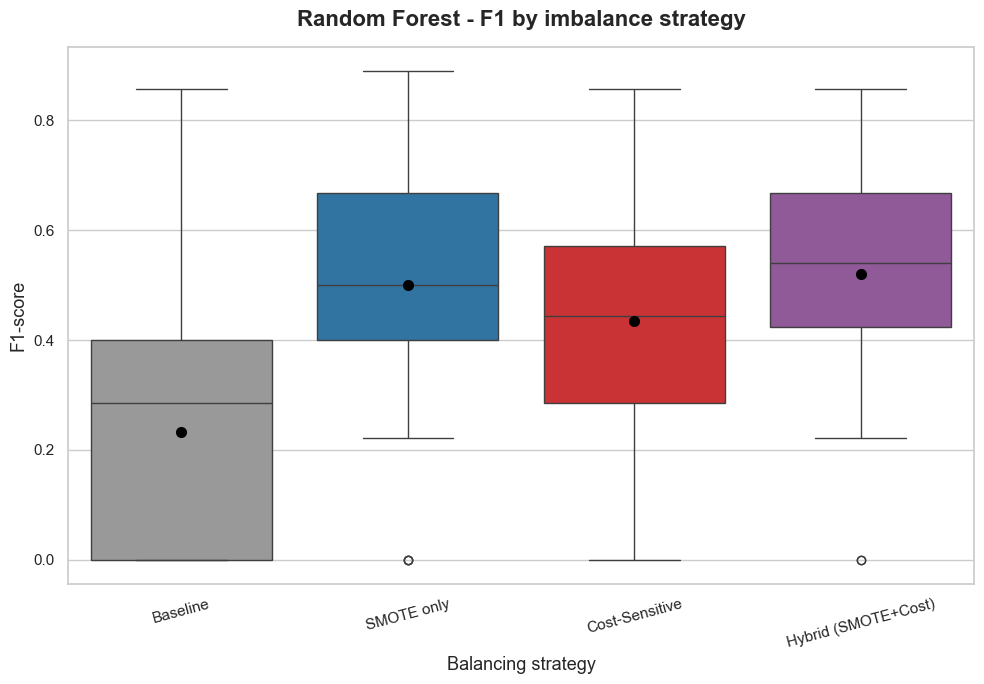

In [15]:
# ==============================================================================
# 7. BOXPLOT COMPARATIVO
# ==============================================================================
print("\n -> Generating Comparative Boxplot...")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

colors = {
    'Baseline': '#999999',
    'SMOTE only': '#1f78b4',
    'Cost-Sensitive': '#e31a1c',
    'Hybrid (SMOTE+Cost)': '#984ea3'
}

ax = sns.boxplot(
    data=df_results,
    x='Mode',
    y='F1',
    palette=colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": "7"
    }
)

ax.set_title('Random Forest - F1 by imbalance strategy', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Balancing strategy', fontsize=13)
ax.set_ylabel('F1-score', fontsize=13)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/RF_comparative_boxplot_F1.png", dpi=300, bbox_inches='tight')
plt.show()

 -> Generating Confusion Matrices (Median Cases)...


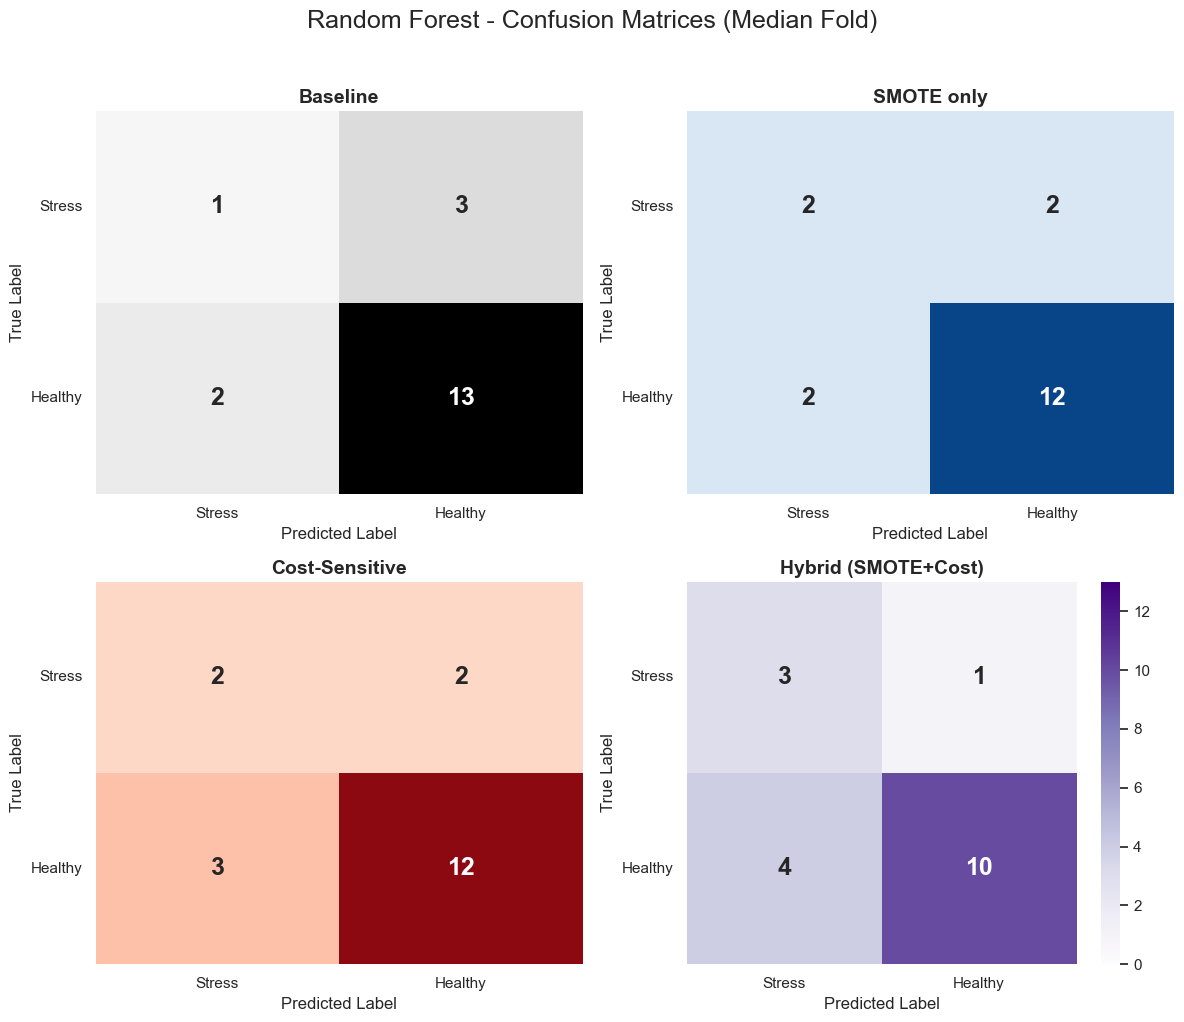

In [16]:
# ==============================================================================
# 8. CONFUSION MATRICES
# ==============================================================================
print(" -> Generating Confusion Matrices (Median Cases)...")

global_max = np.max([median_cm_data[mode] for mode in median_cm_data])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

mode_order = ['Baseline', 'SMOTE only', 'Cost-Sensitive', 'Hybrid (SMOTE+Cost)']
cmaps = ['Greys', 'Blues', 'Reds', 'Purples']

for idx, mode in enumerate(mode_order):
    cm = median_cm_data[mode]
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmaps[idx],
        ax=axes[idx],
        annot_kws={"size": 18, "weight": "bold"},
        vmin=0,
        vmax=global_max,
        cbar=(idx == 3)
    )
    axes[idx].set_title(mode, fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].set_ylabel('True Label', fontsize=12)
    axes[idx].set_xticklabels(['Stress', 'Healthy'], fontsize=11)
    axes[idx].set_yticklabels(['Stress', 'Healthy'], fontsize=11, rotation=0)

plt.suptitle("Random Forest - Confusion Matrices (Median Fold)", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/RF_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

Tamaño TEST: 24
Casos de estrés en TEST: 7

=== RESULTADOS EN TEST ===
Accuracy : 0.833
Recall   : 0.429
Precision: 1.000
F1-score : 0.600


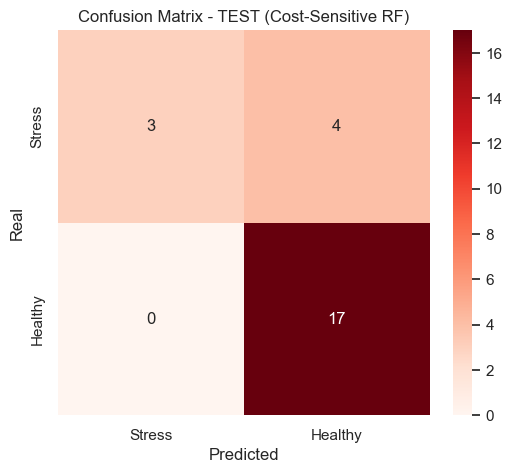

In [19]:
# %%
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. CARGAR DATASET
# =========================
df = pd.read_csv('dataset_learning_24h_clasificador.csv')

features = [
    'radiacion_sum_t+1',
    'radiacion_sum_t0',
    'radiacion_sum_t-1',
    'HA_min_t+1',
    'HS30_min_t+1'
]

# =========================
# 2. SEPARAR TEST
# =========================
df_test = df[df['Set_Type'] == 'Test_Temporal']

X_test = df_test[features]
y_test = df_test['Target_Class']

print("Tamaño TEST:", X_test.shape[0])
print("Casos de estrés en TEST:", y_test.sum())

# =========================
# 3. CARGAR MODELO GANADOR
# =========================
model = joblib.load('rf_newvars_nested_cv/model_Cost-Sensitive_RF_final.pkl')

# =========================
# 4. PREDICCIONES
# =========================
y_pred = model.predict(X_test)

# =========================
# 5. MÉTRICAS
# =========================
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n=== RESULTADOS EN TEST ===")
print(f"Accuracy : {acc:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"Precision: {prec:.3f}")
print(f"F1-score : {f1:.3f}")

# =========================
# 6. MATRIZ DE CONFUSIÓN
# =========================
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Stress', 'Healthy'],
            yticklabels=['Stress', 'Healthy'])

plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix - TEST (Cost-Sensitive RF)')
plt.show()

XGBOOST

In [23]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import xgboost as xgb

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from tqdm import tqdm

# ==============================================================================
# 0. GPU DETECTOR FOR XGBOOST PORTABILITY
# ==============================================================================
def get_xgb_device():
    try:
        xgb.train(
            {'tree_method': 'hist', 'device': 'cuda'},
            xgb.DMatrix(np.array([[0]]), label=np.array([0])),
            num_boost_round=1
        )
        print(" -> GPU NVIDIA detected (CUDA enabled for XGBoost)")
        return 'cuda'
    except Exception:
        print(" -> GPU not detected. Falling back to CPU.")
        return 'cpu'

XGB_DEVICE = get_xgb_device()

# ==============================================================================
# 1. SETUP & CONFIGURATION
# ==============================================================================
np.random.seed(42)
OUTPUT_DIR = 'xgb_newvars_nested_cv'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

FILE_DATA = 'dataset_learning_24h_clasificador.csv'

N_SPLITS = 5
N_REPEATS = 10
N_ITERACIONES = N_SPLITS * N_REPEATS

N_ITER_SEARCH = 30
CV_INNER_FOLDS = 3

print(f"\n--- STARTING XGBOOST NESTED CROSS-VALIDATION EXPERIMENT ---")
print(f" -> Architecture: {N_SPLITS}-Fold RSKF repeated {N_REPEATS} times ({N_ITERACIONES} Outer Folds)")
print(f" -> Saving outputs to: {OUTPUT_DIR}/")

 -> GPU NVIDIA detected (CUDA enabled for XGBoost)

--- STARTING XGBOOST NESTED CROSS-VALIDATION EXPERIMENT ---
 -> Architecture: 5-Fold RSKF repeated 10 times (50 Outer Folds)
 -> Saving outputs to: xgb_newvars_nested_cv/


C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [18:37:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [18:37:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# ==============================================================================
# 2. LOAD DATA & FILTER FEATURES
# ==============================================================================
df = pd.read_csv(FILE_DATA)

features = [
    'radiacion_sum_t+1',
    'radiacion_sum_t0',
    'radiacion_sum_t-1',
    'HA_min_t+1',
    'HS30_min_t+1'
]

X_full = df[features]
y_full = df['Target_Class']

idx_train = df[df['Set_Type'] == 'Train_CV'].index
X_train_cv = X_full.loc[idx_train].reset_index(drop=True)
y_train_cv = y_full.loc[idx_train].reset_index(drop=True)

print(f" -> TRAIN_CV SET: {X_train_cv.shape[0]} samples")
print(f" -> Stress cases in TRAIN_CV: {y_train_cv.sum()}")
print("\nVariables usadas:")
print(features)

 -> TRAIN_CV SET: 93 samples
 -> Stress cases in TRAIN_CV: 20

Variables usadas:
['radiacion_sum_t+1', 'radiacion_sum_t0', 'radiacion_sum_t-1', 'HA_min_t+1', 'HS30_min_t+1']


In [ ]:
# ==============================================================================
# 3. HYPERPARAMETER DISTRIBUTIONS
# ==============================================================================

grid_xgb_std = {
    'classifier__n_estimators': [50, 100, 150, 200],
    'classifier__max_depth': [1, 2, 3, 4],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.5, 0.8, 1.0],
    'classifier__reg_lambda': [1, 5, 10],
    'classifier__min_child_weight': [1, 2, 5]
}

smote_params = {
    'smote__k_neighbors': [2, 3, 5]
}

rango_pesos = [2.0, 3.0, 4.0, 5.0, 6.0]
grid_xgb_cost = grid_xgb_std.copy()
grid_xgb_cost['classifier__scale_pos_weight'] = rango_pesos

In [ ]:
# ==============================================================================
# 4. NESTED CROSS-VALIDATION LOOP
# ==============================================================================
results_all = []
candidates = {
    'Baseline': [],
    'SMOTE only': [],
    'Cost-Sensitive': [],
    'Hybrid (SMOTE+Cost)': []
}

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

for i, (train_idx, val_idx) in enumerate(
    tqdm(rskf.split(X_train_cv, y_train_cv), total=N_ITERACIONES, desc="Nested CV Loop")
):
    X_t, y_t = X_train_cv.iloc[train_idx], y_train_cv.iloc[train_idx]
    X_v, y_v = X_train_cv.iloc[val_idx], y_train_cv.iloc[val_idx]

    pipe_base = ImbPipeline([
        ('scaler', StandardScaler()),
        ('classifier', xgb.XGBClassifier(
            eval_metric='logloss',
            tree_method='hist',
            device=XGB_DEVICE,
            random_state=i
        ))
    ])

    pipe_smote = ImbPipeline([
        ('smote', SMOTE(random_state=i)),
        ('scaler', StandardScaler()),
        ('classifier', xgb.XGBClassifier(
            eval_metric='logloss',
            tree_method='hist',
            device=XGB_DEVICE,
            random_state=i
        ))
    ])

    configs = [
        ('Baseline', pipe_base, grid_xgb_std),
        ('SMOTE only', pipe_smote, {**grid_xgb_std, **smote_params}),
        ('Cost-Sensitive', pipe_base, grid_xgb_cost),
        ('Hybrid (SMOTE+Cost)', pipe_smote, {**grid_xgb_cost, **smote_params})
    ]

    for mode, pipeline, grid in configs:
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=grid,
            n_iter=N_ITER_SEARCH,
            cv=StratifiedKFold(n_splits=CV_INNER_FOLDS, shuffle=True, random_state=i),
            scoring='f1',
            n_jobs=-1,
            random_state=i
        )

        search.fit(X_t, y_t)
        best_fold_model = search.best_estimator_

        preds_val = best_fold_model.predict(X_v)

        met = {
            'Accuracy': accuracy_score(y_v, preds_val),
            'Recall': recall_score(y_v, preds_val, pos_label=1, zero_division=0),
            'Precision': precision_score(y_v, preds_val, pos_label=1, zero_division=0),
            'F1': f1_score(y_v, preds_val, pos_label=1, zero_division=0)
        }

        results_all.append({
            'Iteration': i,
            'Mode': mode,
            'Model': 'XGB',
            **met
        })

        cm = confusion_matrix(y_v, preds_val, labels=[1, 0])

        candidates[mode].append({
            'params': search.best_params_,
            'metrics': met,
            'cm': cm,
            'iter': i,
            'best_model': best_fold_model
        })

Nested CV Loop:   0%|          | 0/50 [00:00<?, ?it/s]C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [18:38:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [18:38:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [18:38:53] WARNING: C:\actions

In [ ]:
# ==============================================================================
# 5. SELECT MEDIAN PARAMS, RETRAIN FINAL MODELS & SAVE
# ==============================================================================
print("\n--- EXTRACTING MEDIAN HYPERPARAMETERS & RETRAINING FULL TRAIN_CV ---")

median_params_summary = []
median_cm_data = {}

for mode in candidates.keys():
    runs = candidates[mode]
    runs_sorted = sorted(runs, key=lambda x: x['metrics']['F1'])
    median_run = runs_sorted[len(runs_sorted)//2]

    median_cm_data[mode] = median_run['cm']

    final_pipe = median_run['best_model']
    final_pipe.fit(X_train_cv, y_train_cv)

    safe_mode = mode.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')
    filename = f"model_{safe_mode}_XGB_final.pkl"
    joblib.dump(final_pipe, os.path.join(OUTPUT_DIR, filename))

    best_params = median_run['params']
    clean_params = {
        k.replace('classifier__', '').replace('smote__', ''): v
        for k, v in best_params.items()
    }

    median_params_summary.append({
        'Mode': mode,
        'Model': 'XGB',
        'Best_Params': str(clean_params),
        'Median_F1_Val': median_run['metrics']['F1']
    })

df_params = pd.DataFrame(median_params_summary)
df_params.to_csv(f"{OUTPUT_DIR}/median_models_parameters.csv", index=False)

print("\nModelos finales guardados en:")
print(OUTPUT_DIR)


--- EXTRACTING MEDIAN HYPERPARAMETERS & RETRAINING FULL TRAIN_CV ---

Modelos finales guardados en:
xgb_newvars_nested_cv


C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [18:40:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [18:40:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [18:40:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No vi

In [ ]:
# ==============================================================================
# 6. SUMMARY TABLE
# ==============================================================================
df_results = pd.DataFrame(results_all)

summary = df_results.groupby(['Mode', 'Model'])[['Accuracy', 'Recall', 'Precision', 'F1']].agg(['mean', 'std'])
summary.to_csv(f"{OUTPUT_DIR}/metrics_summary_table.csv")

print(summary)

                           Accuracy           Recall           Precision  \
                               mean       std   mean       std      mean   
Mode                Model                                                  
Baseline            XGB    0.770819  0.055248  0.200  0.174964  0.383714   
Cost-Sensitive      XGB    0.700234  0.129497  0.575  0.291241  0.396065   
Hybrid (SMOTE+Cost) XGB    0.686725  0.125736  0.750  0.220158  0.411596   
SMOTE only          XGB    0.747778  0.103972  0.590  0.240959  0.461373   

                                           F1            
                                std      mean       std  
Mode                Model                                
Baseline            XGB    0.358468  0.244447  0.197814  
Cost-Sensitive      XGB    0.189219  0.444265  0.191723  
Hybrid (SMOTE+Cost) XGB    0.149570  0.514623  0.138581  
SMOTE only          XGB    0.224162  0.499666  0.195124  



 -> Generating Comparative Boxplot...


C:\Users\Iratxe\AppData\Local\Temp\ipykernel_9332\443509412.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


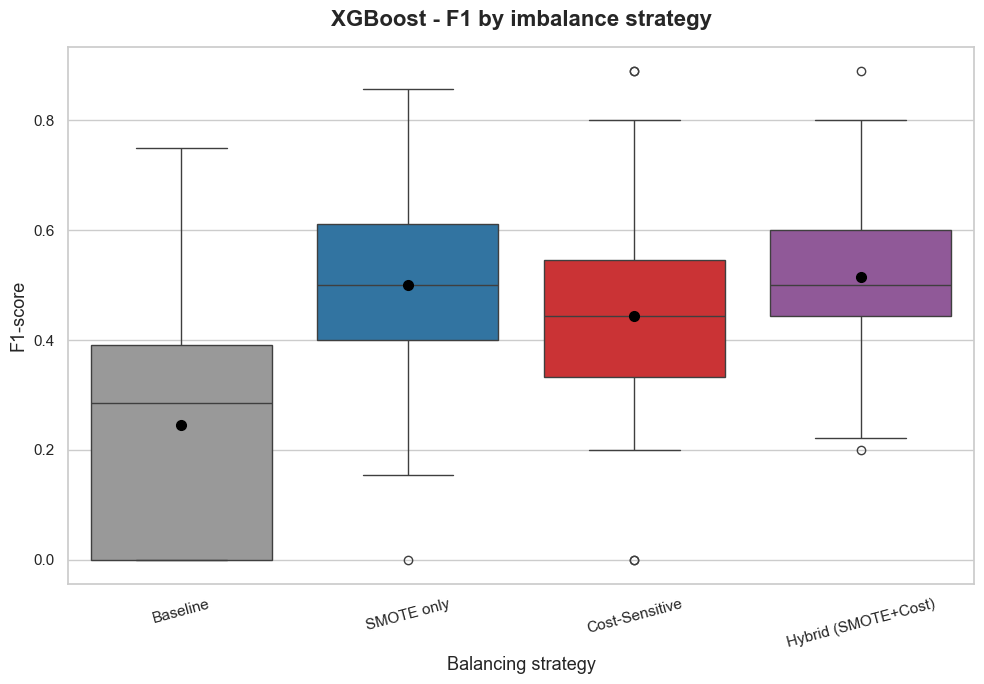

In [ ]:
# ==============================================================================
# 7. BOXPLOT COMPARATIVO
# ==============================================================================
print("\n -> Generating Comparative Boxplot...")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

colors = {
    'Baseline': '#999999',
    'SMOTE only': '#1f78b4',
    'Cost-Sensitive': '#e31a1c',
    'Hybrid (SMOTE+Cost)': '#984ea3'
}

ax = sns.boxplot(
    data=df_results,
    x='Mode',
    y='F1',
    palette=colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": "7"
    }
)

ax.set_title('XGBoost - F1 by imbalance strategy', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Balancing strategy', fontsize=13)
ax.set_ylabel('F1-score', fontsize=13)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/XGB_comparative_boxplot_F1.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
mean_f1 = (
    df_results.groupby('Mode')['F1']
    .mean()
    .sort_values(ascending=False)
)

print("=== F1 medio por estrategia (XGBoost) ===")
print(mean_f1)

=== F1 medio por estrategia (XGBoost) ===
Mode
Hybrid (SMOTE+Cost)    0.514623
SMOTE only             0.499666
Cost-Sensitive         0.444265
Baseline               0.244447
Name: F1, dtype: float64



=== RESULTADOS EN TEST (XGBoost) ===
Accuracy : 0.792
Recall   : 0.714
Precision: 0.625
F1-score : 0.667


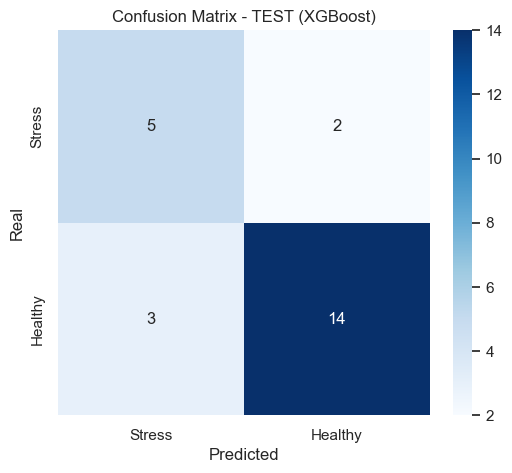

In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_learning_24h_clasificador.csv')

features = [
    'radiacion_sum_t+1',
    'radiacion_sum_t0',
    'radiacion_sum_t-1',
    'HA_min_t+1',
    'HS30_min_t+1'
]

df_test = df[df['Set_Type'] == 'Test_Temporal']
X_test = df_test[features]
y_test = df_test['Target_Class']

model = joblib.load('xgb_newvars_nested_cv/model_Cost-Sensitive_XGB_final.pkl')

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n=== RESULTADOS EN TEST (XGBoost) ===")
print(f"Accuracy : {acc:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"Precision: {prec:.3f}")
print(f"F1-score : {f1:.3f}")

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stress', 'Healthy'],
            yticklabels=['Stress', 'Healthy'])
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix - TEST (XGBoost)')
plt.show()